<a href="https://colab.research.google.com/github/TaicirCheikhrouhou/IDSproject-QGAN-AE-RL-FL/blob/main/QGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Quantum Generative Adversarial Network (QGAN) for NSL-KDD Intrusion Detection**

![Python](https://img.shields.io/badge/Python-3.9+-blue.svg)
![PyTorch](https://img.shields.io/badge/PyTorch-Deep%20Learning-red)
![Qiskit](https://img.shields.io/badge/Qiskit-Quantum%20ML-purple)
![Research](https://img.shields.io/badge/Project-Research-orange)
![IDS](https://img.shields.io/badge/Domain-Cybersecurity-black)
![Colab](https://img.shields.io/badge/Google-Colab-yellow)
![CPU](https://img.shields.io/badge/Hardware-CPU%20Only-lightgrey)
![GAN](https://img.shields.io/badge/Model-QGAN-blueviolet)
![RL](https://img.shields.io/badge/Learning-Adversarial%20RL-green)
![Dataset](https://img.shields.io/badge/Dataset-NSL--KDD-informational)

**Description:** Hybrid Quantum-Classical GAN for generating synthetic network intrusion data

## 📋 Table of Contents
1. [Setup & Imports](#setup)
2. [Configuration & Hyperparameters](#config)
3. [Model Architectures](#models)
4. [Utility Functions](#helpers)
5. [Data Preprocessing](#data)
6. [Training Functions](#training)
7. [Execution & Results](#execution)

---

## Project Overview

This notebook presents an exploratory research implementation of a **Quantum Generative Adversarial Network (QGAN)**
for data augmentation in Intrusion Detection Systems (IDS).

The main objective is to mitigate class imbalance in network intrusion datasets by generating realistic synthetic samples
using a quantum-inspired generative model trained in the latent space of an autoencoder.

Due to hardware and resource constraints, experiments are conducted on the NSL-KDD dataset using a hybrid
quantum–classical pipeline.

In [ ]:
!pip install qiskit qiskit-machine-learning qiskit-algorithms torch torchvision seaborn pandas scikit-learn matplotlib tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.6 MB/s eta 0:00:00



# 1. SETUP & IMPORTS


In [ ]:
# Mount Google Drive (for Colab environment)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("📦 Importing libraries...")

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from datetime import datetime

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import wasserstein_distance

# Qiskit (updated for 1.0+)
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import ZZFeatureMap, EfficientSU2
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_algorithms.utils import algorithm_globals

# IPython display for live plotting
from IPython.display import clear_output

print("✅ All libraries imported successfully!\n")

📦 Importing libraries...
✅ All libraries imported successfully!



In [ ]:
# ============================================================================
# 2. CONFIGURATION & HYPERPARAMETERS
# ============================================================================

print("⚙️ Setting hyperparameters...\n")

# Autoencoder parameters
LATENT_DIM = 7
AE_EPOCHS = 50
AE_BATCH_SIZE = 128
AE_LR = 1e-3

# Quantum circuit parameters
Q_REPS = 2
Q_ENTANGLEMENT = 'full'

# GAN architecture parameters
DISCRIM_HIDDEN = 128
LR_G = 2e-2
LR_D = 5e-3

# Training parameters
EPOCHS = 20
BATCH = 16
SUBSET_SIZE = 256
SEED = 42
WARMUP_EPOCHS = 2

# Early stopping parameters
EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 0.001

# Reproducibility
algorithm_globals.random_seed = SEED
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}\n")

print("=" * 70)
print("HYPERPARAMETERS SUMMARY")
print("=" * 70)
print(f"Latent Dimension:      {LATENT_DIM}")
print(f"Autoencoder Epochs:    {AE_EPOCHS}")
print(f"QGAN Epochs:           {EPOCHS}")
print(f"Batch Size:            {BATCH}")
print(f"Learning Rate G:       {LR_G}")
print(f"Learning Rate D:       {LR_D}")
print(f"Early Stop Patience:   {EARLY_STOP_PATIENCE}")
print(f"Quantum Reps:          {Q_REPS}")
print(f"Quantum Entanglement:  {Q_ENTANGLEMENT}")
print("=" * 70)
print()

⚙️ Setting hyperparameters...

 Using device: cpu

HYPERPARAMETERS SUMMARY
Latent Dimension:      7
Autoencoder Epochs:    50
QGAN Epochs:           20
Batch Size:            16
Learning Rate G:       0.02
Learning Rate D:       0.005
Early Stop Patience:   5
Quantum Reps:          2
Quantum Entanglement:  full



# 3. MODEL ARCHITECTURES


In [ ]:
print("  Defining model architectures...\n")

# -----------------------------------------------------------------------------
# 3.1 Autoencoder for Dimensionality Reduction
# -----------------------------------------------------------------------------

class AutoEncoder(nn.Module):
    """
    Simple MLP Autoencoder for non-linear feature extraction.

    Architecture:
    - Encoder: Input -> 128 -> 64 -> Latent
    - Decoder: Latent -> 64 -> 128 -> Output
    """
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

print("✅ Autoencoder defined")

# -----------------------------------------------------------------------------
# 3.2 Classical Discriminator Network
# -----------------------------------------------------------------------------

class Discriminator(nn.Module):
    """
    Classical discriminator network for WGAN-GP.

    Architecture:
    - Input -> Hidden -> Hidden/2 -> 1 (Wasserstein distance estimate)
    - Uses LayerNorm, LeakyReLU, and Dropout for stability
    """
    def __init__(self, input_dim, hidden_dim=DISCRIM_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x)

print("✅ Discriminator defined")

# -----------------------------------------------------------------------------
# 3.3 Quantum Generator (SamplerQNN)
# -----------------------------------------------------------------------------

def make_sampler_generator(num_features, reps=Q_REPS, entanglement=Q_ENTANGLEMENT,
                          seed=SEED, shots=10_000):
    """
    Create a TorchConnector-wrapped SamplerQNN generator.

    Quantum Circuit Architecture:
    1. Rx rotation gates for latent inputs
    2. ZZFeatureMap for feature encoding
    3. EfficientSU2 variational form (trainable parameters)

    Args:
        num_features: Number of features (qubits)
        reps: Number of repetitions in ansatz
        entanglement: Entanglement strategy ('full', 'linear', etc.)
        seed: Random seed
        shots: Number of shots for sampling

    Returns:
        TorchConnector wrapping the SamplerQNN
    """
    algorithm_globals.random_seed = seed
    np.random.seed(seed)
    torch.manual_seed(seed)

    sampler = Sampler()
    qc = QuantumCircuit(num_features)
    inp = ParameterVector('z', num_features)

    # Input encoding
    for i in range(num_features):
        qc.rx(inp[i], i)

    # Feature map
    qc.compose(ZZFeatureMap(num_features, reps=1, entanglement=entanglement), inplace=True)

    # Variational ansatz
    qc.compose(EfficientSU2(num_features, reps=reps, entanglement=entanglement), inplace=True)

    # Create QNN
    qnn = SamplerQNN(
        circuit=qc,
        sampler=sampler,
        input_params=inp,
        weight_params=qc.parameters[len(inp):],
        output_shape=2**num_features,
    )

    # Initialize weights
    init_w = torch.randn(qnn.num_weights, dtype=torch.float32) * 0.02

    return TorchConnector(qnn, initial_weights=init_w)

print("✅ Quantum Generator factory defined")

# -----------------------------------------------------------------------------
# 3.4 Marginal Decoding Function
# -----------------------------------------------------------------------------

def marginal_decode(prob_matrix: torch.Tensor) -> torch.Tensor:
    """
    Decode full probability vector from SamplerQNN into continuous features.

    For each qubit i, computes the marginal probability that qubit i is in state |1⟩
    by summing over all basis states where qubit i is 1.

    Args:
        prob_matrix: (batch, 2^n) probability distribution from quantum circuit

    Returns:
        (batch, n) continuous values in [0, 1]
    """
    batch, total = prob_matrix.shape
    n = int(np.log2(total))
    device = prob_matrix.device
    out = torch.zeros(batch, n, device=device)

    for i in range(n):
        block = 1 << i
        stride = 1 << (i + 1)
        unfolded = prob_matrix.unfold(1, stride, stride)[:, :, block:]
        out[:, i] = unfolded.sum(dim=2).sum(dim=1)

    return out.clamp(0.0, 1.0)

print("✅ Marginal decoder defined\n")

🏗️  Defining model architectures...

✅ Autoencoder defined
✅ Discriminator defined
✅ Quantum Generator factory defined
✅ Marginal decoder defined



# 4. UTILITY FUNCTIONS


In [ ]:
print("🔧 Defining utility functions...\n")

# -----------------------------------------------------------------------------
# 4.1 Early Stopping Class
# -----------------------------------------------------------------------------

class EarlyStopping:
    """
    Early stopping to halt training when metric stops improving.

    Args:
        patience: Number of epochs without improvement before stopping
        min_delta: Minimum change to be considered an improvement
        mode: 'min' to minimize metric, 'max' to maximize
    """
    def __init__(self, patience=5, min_delta=0.001, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return False

        if self.mode == 'min':
            improved = (self.best_score - current_score) > self.min_delta
        else:
            improved = (current_score - self.best_score) > self.min_delta

        if improved:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

        return self.early_stop

print("✅ Early stopping class defined")

# -----------------------------------------------------------------------------
# 4.2 Gradient Penalty for WGAN-GP
# -----------------------------------------------------------------------------

def gradient_penalty(discriminator, real_samples, fake_samples, device):
    """
    Compute gradient penalty for WGAN-GP to enforce Lipschitz constraint.

    The gradient penalty ensures the discriminator is 1-Lipschitz continuous
    by penalizing gradients that deviate from norm 1.

    Args:
        discriminator: The discriminator network
        real_samples: Batch of real samples
        fake_samples: Batch of fake samples
        device: torch device

    Returns:
        Gradient penalty loss term
    """
    batch_size = real_samples.size(0)
    alpha = torch.rand(batch_size, 1, device=device).expand_as(real_samples)

    # Interpolate between real and fake
    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates.requires_grad_(True)

    d_interpolates = discriminator(interpolates)

    # Compute gradients
    grad_outputs = torch.ones_like(d_interpolates, device=device)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()

    return gp

print("✅ Gradient penalty function defined")

# -----------------------------------------------------------------------------
# 4.3 Visualization: Fake Data Reconstruction
# -----------------------------------------------------------------------------

def visualize_fake_reconstruction(ae, fake_samples, class_name, timestamp, drive_base):
    """
    Visualize autoencoder reconstruction quality on synthetic data.

    This function helps validate that the synthetic data generated by the QGAN
    can be properly decoded back to the original feature space through the
    autoencoder's decoder.

    Args:
        ae: Trained autoencoder
        fake_samples: Synthetic samples in latent space (numpy array)
        class_name: Attack class name
        timestamp: Timestamp for file naming
        drive_base: Base path for saving plots
    """
    ae.eval()

    # Convert to tensor
    fake_tensor = torch.tensor(fake_samples, dtype=torch.float32).to(device)

    with torch.no_grad():
        # Decode to original space
        reconstructed = ae.decoder(fake_tensor).cpu().numpy()

        # Re-encode to latent space
        reconstructed_tensor = torch.tensor(reconstructed, dtype=torch.float32).to(device)
        re_encoded = ae.encoder(reconstructed_tensor).cpu().numpy()

    # Compute reconstruction MSE
    mse = np.mean((fake_samples - re_encoded) ** 2)
    print(f"MSE Reconstruction (Fake {class_name}): {mse:.6f}")

    # Visualization 1: Scatter plot original vs re-encoded
    num_samples = min(100, fake_samples.shape[0])
    num_features_vis = min(LATENT_DIM, fake_samples.shape[1])
    idx_samples = np.random.choice(fake_samples.shape[0], num_samples, replace=False)

    original = fake_samples[idx_samples, :num_features_vis]
    re_enc = re_encoded[idx_samples, :num_features_vis]

    plt.figure(figsize=(12, 8))
    for i in range(num_features_vis):
        plt.scatter(original[:, i], re_enc[:, i], alpha=0.5, label=f'Latent {i+1}')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect reconstruction')
    plt.xlabel('Original Fake Latent Values')
    plt.ylabel('Re-encoded Latent Values')
    plt.title(f'Fake Data Reconstruction Quality - {class_name}\nMSE: {mse:.6f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plot_path = drive_base + f"plots/fake_reconstruction_{class_name}_{timestamp}.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Fake reconstruction plot saved: {plot_path}")

    # Visualization 2: Distribution of reconstruction errors
    plt.figure(figsize=(10, 5))
    errors = np.abs(fake_samples - re_encoded)

    plt.subplot(1, 2, 1)
    plt.hist(errors.flatten(), bins=50, alpha=0.7, color='tab:blue')
    plt.xlabel('Absolute Reconstruction Error')
    plt.ylabel('Frequency')
    plt.title('Distribution of Reconstruction Errors')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    mean_errors_per_feature = errors.mean(axis=0)
    plt.bar(range(len(mean_errors_per_feature)), mean_errors_per_feature, color='tab:orange')
    plt.xlabel('Latent Feature Index')
    plt.ylabel('Mean Absolute Error')
    plt.title('Reconstruction Error per Latent Feature')
    plt.grid(True, alpha=0.3)

    plt.suptitle(f'Fake Data Reconstruction Analysis - {class_name}', fontsize=14)
    plt.tight_layout()

    plot_path = drive_base + f"plots/fake_reconstruction_errors_{class_name}_{timestamp}.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Reconstruction errors plot saved: {plot_path}")

print("✅ Visualization function defined\n")

🔧 Defining utility functions...

✅ Early stopping class defined
✅ Gradient penalty function defined
✅ Visualization function defined



# 5. DATA PREPROCESSING

In [ ]:
print("📊 Defining data preprocessing pipeline...\n")

def load_and_preprocess_data():
    """
    Load NSL-KDD dataset, preprocess, and apply Autoencoder for dimensionality reduction.

    Pipeline:
    1. Load NSL-KDD training data
    2. Map attack labels to categories
    3. Scale numerical features (Robust + MinMax)
    4. One-hot encode categorical features
    5. Train autoencoder for dimensionality reduction
    6. Transform data to latent space
    7. Split by attack type for class-specific QGAN training

    Returns:
        qgan_data: Dict of train/test splits per attack class
        ae: Trained autoencoder model
    """
    print("Loading NSL-KDD dataset...")

    # Column names for NSL-KDD
    col_names = [
        "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
        "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
        "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
        "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
        "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
        "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
        "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
        "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
    ]

    train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
    df = pd.read_csv(train_url, names=col_names)
    df.drop(columns=['difficulty'], inplace=True)

    print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

    # Map attack labels to categories
    attack_map = {
        'normal': 'Normal',
        'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS',
        'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS',
        'udpstorm': 'DoS',
        'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
        'mscan': 'Probe', 'saint': 'Probe',
        'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
        'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
        'sendmail': 'R2L', 'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
        'xlock': 'R2L', 'xsnoop': 'R2L', 'worm': 'R2L',
        'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
        'httptunnel': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R'
    }

    df['attack_type'] = df['label'].map(attack_map)

    print("\n📈 Attack type distribution:")
    print(df['attack_type'].value_counts())

    # Separate numerical and categorical features
    categorical_cols = ['protocol_type', 'service', 'flag']
    numeric_cols = [c for c in df.columns if c not in categorical_cols + ['label', 'attack_type']]

    # Scale numerical features
    print("\n🔢 Scaling numerical features...")
    df[numeric_cols] = df[numeric_cols].fillna(0)
    robust = RobustScaler()
    minmax = MinMaxScaler()
    df_num = df[numeric_cols].values
    df_num = robust.fit_transform(df_num)
    df_num = minmax.fit_transform(df_num)
    df_scaled = pd.DataFrame(df_num, columns=numeric_cols)

    # One-hot encode categorical features
    print("🔤 Encoding categorical features...")
    cat_encoded = pd.get_dummies(df[categorical_cols].astype(str), dtype=float)

    # Combine features
    X_all = pd.concat([df_scaled.reset_index(drop=True), cat_encoded.reset_index(drop=True)], axis=1)
    y_all = df['attack_type'].reset_index(drop=True)

    print(f"\n✅ Final feature matrix: {X_all.shape}")

    # Shuffle and split
    X_all, y_all = shuffle(X_all, y_all, random_state=SEED)
    X_all_train, X_all_val = train_test_split(X_all, test_size=0.2, random_state=SEED)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_all_train.values, dtype=torch.float32).to(device)
    X_val_tensor = torch.tensor(X_all_val.values, dtype=torch.float32).to(device)
    X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)

    # -------------------------------------------------------------------------
    # Train Autoencoder
    # -------------------------------------------------------------------------
    print(f"\n🤖 Training Autoencoder ({AE_EPOCHS} epochs)...")

    input_dim = X_all.shape[1]
    ae = AutoEncoder(input_dim, LATENT_DIM).to(device)
    optimizer = optim.Adam(ae.parameters(), lr=AE_LR)
    criterion = nn.MSELoss()

    from torch.utils.data import DataLoader, TensorDataset
    train_dataset = TensorDataset(X_train_tensor)
    train_dataloader = DataLoader(train_dataset, batch_size=AE_BATCH_SIZE, shuffle=True)

    for epoch in tqdm(range(AE_EPOCHS)):
        ae.train()
        for batch in train_dataloader:
            inputs = batch[0]
            outputs = ae(inputs)
            loss = criterion(outputs, inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluate autoencoder
    ae.eval()
    with torch.no_grad():
        outputs_train = ae(X_train_tensor)
        train_loss = criterion(outputs_train, X_train_tensor)
        outputs_val = ae(X_val_tensor)
        val_loss = criterion(outputs_val, X_val_tensor)

    print(f"\n📊 Autoencoder Evaluation:")
    print(f"   Train MSE: {train_loss.item():.4f}")
    print(f"   Val MSE:   {val_loss.item():.4f}")

    # Visualization: Reconstruction quality
    print("\n📈 Visualizing reconstruction quality...")
    with torch.no_grad():
        num_samples = min(100, X_val_tensor.shape[0])
        num_features_vis = min(10, input_dim)
        idx_samples = torch.randperm(X_val_tensor.shape[0])[:num_samples]
        idx_features = torch.randperm(input_dim)[:num_features_vis]

        original = X_val_tensor[idx_samples, :][:, idx_features].cpu().numpy()
        reconstructed = outputs_val[idx_samples, :][:, idx_features].cpu().numpy()

    plt.figure(figsize=(12, 8))
    for i in range(num_features_vis):
        plt.scatter(original[:, i], reconstructed[:, i], alpha=0.5,
                   label=f'Feature {idx_features[i].item()}')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('Original Values')
    plt.ylabel('Reconstructed Values')
    plt.title('Autoencoder Reconstruction: Original vs Reconstructed (Subset)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Transform to latent space
    print(f"\n🔄 Transforming to {LATENT_DIM}D latent space...")
    with torch.no_grad():
        X_latent = ae.encoder(X_tensor).cpu().numpy()

    print(f"✅ Latent representation: {X_latent.shape}")

    # Normalize latent features
    X_latent = minmax.fit_transform(X_latent)

    # Split by attack type
    print("\n📦 Splitting data by attack type...")
    qgan_datasets = {}
    for cls in y_all.unique():
        X_cls = X_latent[y_all == cls]
        qgan_datasets[cls] = pd.DataFrame(X_cls, columns=[f'Latent{i+1}' for i in range(LATENT_DIM)])
        print(f"   {cls:>6} -> {X_cls.shape[0]:>6} samples")

    # Create train/test splits for each class
    qgan_data = {}
    for cls, dfc in qgan_datasets.items():
        if dfc.shape[0] < LATENT_DIM + 1:
            print(f"   ⚠️  Skipping {cls} (too few samples)")
            continue

        X_tr, X_te = train_test_split(dfc.values, test_size=0.2, random_state=SEED)
        qgan_data[cls] = {'train': X_tr, 'test': X_te}
        print(f"   {cls}: train {X_tr.shape}, test {X_te.shape}")

    print("\n✅ Data preprocessing complete!")
    return qgan_data, ae

📊 Defining data preprocessing pipeline...



# 6. TRAINING FUNCTION

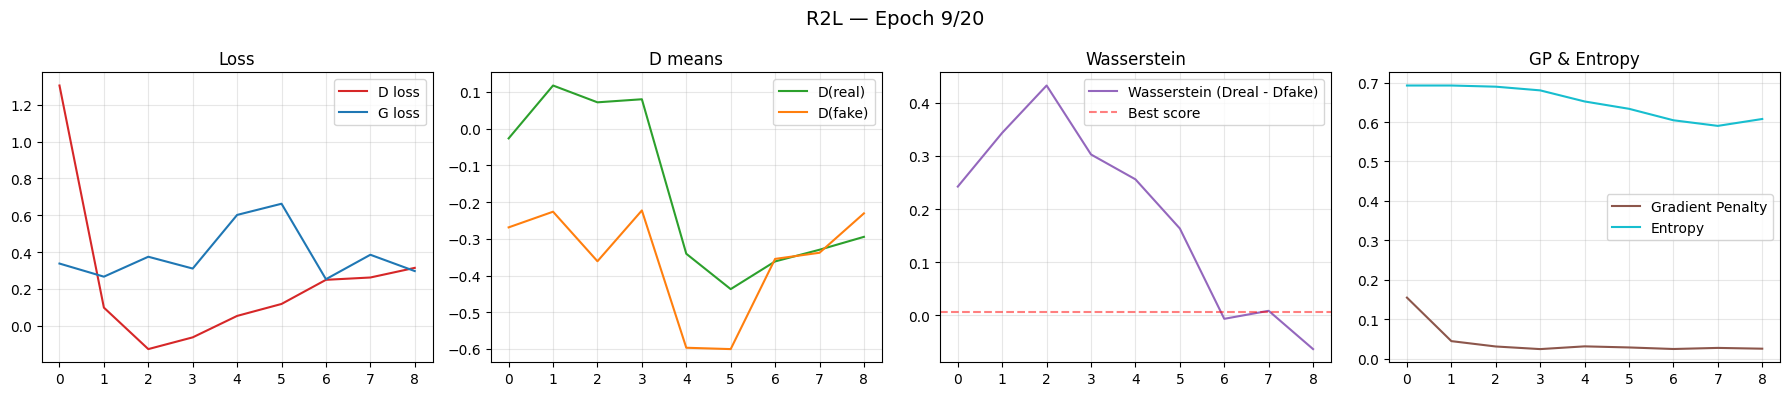

Epoch   9/20 [ES: 2/5] | D_loss=0.3146 | G_loss=0.2972 | Wasserstein=-0.0639 | GP=0.0251 | Entropy=0.608

⚠️  Early stopping triggered at epoch 12/20
    No improvement for 5 epochs
    Best Wasserstein: 0.0069

✅ Training complete for R2L!
💾 Checkpoint saved: /content/drive/MyDrive/QGAN_Outputs/checkpoints/qgan_R2L_20260111-165010.pt

🎲 Generating synthetic samples...
✅ Generated 30000 synthetic samples

📊 Visualizing synthetic data reconstruction...
MSE Reconstruction (Fake R2L): 0.210164


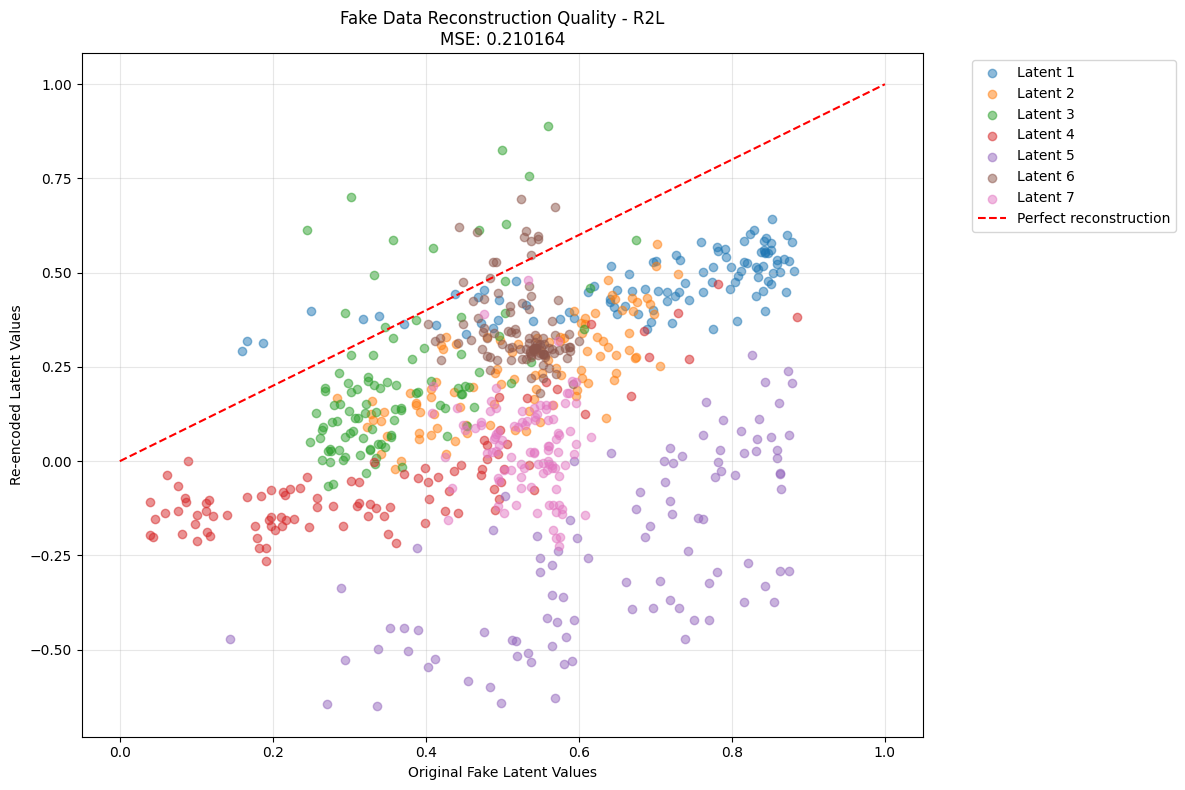

Fake reconstruction plot saved: /content/drive/MyDrive/QGAN_Outputs/plots/fake_reconstruction_R2L_20260111-165010.png


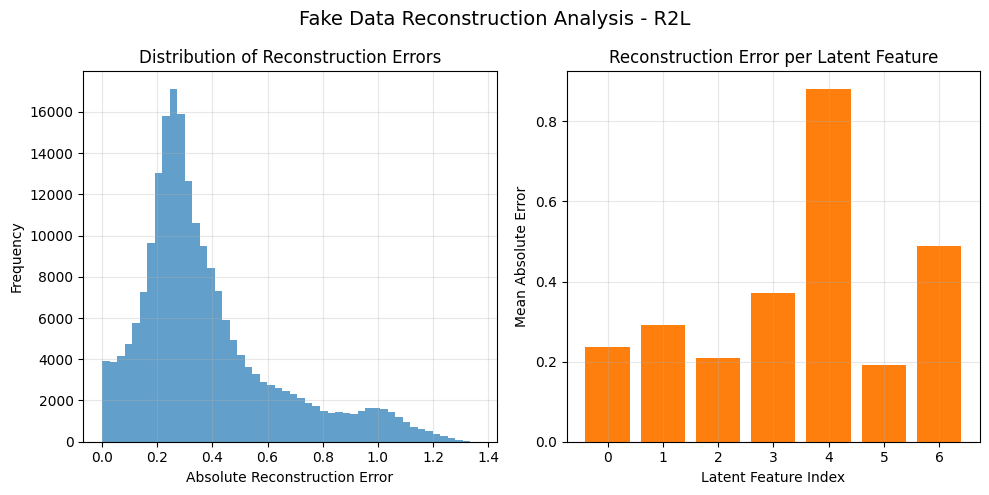

Reconstruction errors plot saved: /content/drive/MyDrive/QGAN_Outputs/plots/fake_reconstruction_errors_R2L_20260111-165010.png

📈 Evaluating generation quality...

📊 EVALUATION RESULTS for R2L:
   AUC (real vs fake): 0.6010
   Wasserstein distance: 0.1103 (avg per latent dim)

📊 Creating final KDE comparison plot...


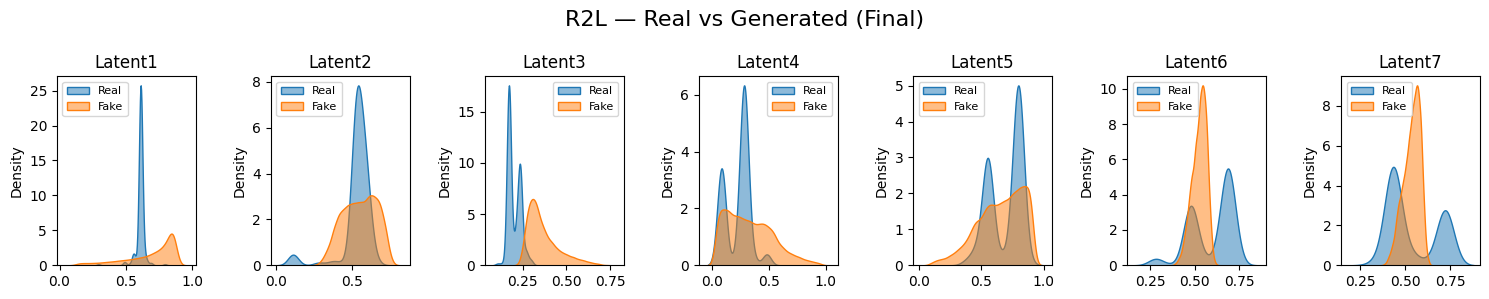

💾 KDE plot saved: /content/drive/MyDrive/QGAN_Outputs/plots/kde_R2L_20260111-165010.png


⚠️  Skipping U2R: not enough samples.



In [9]:
print("🎯 Defining QGAN training function...\n")

def train_hybrid_qgan(class_name, data, num_epochs=EPOCHS, batch_size=BATCH,
                     latent_dim=LATENT_DIM, q_reps=Q_REPS, lr_g=LR_G, lr_d=LR_D,
                     seed=SEED, subset_size=SUBSET_SIZE, warmup=WARMUP_EPOCHS,
                     plot_every=5, lambda_gp=10.0, early_stopping=True):
    """
    Train hybrid Quantum-Classical GAN with WGAN-GP objective and early stopping.

    Training Strategy:
    1. Warmup phase: Only train discriminator
    2. Adversarial phase: Train both generator and discriminator
    3. Early stopping: Monitor Wasserstein distance to prevent overfitting

    Args:
        class_name: Name of attack class
        data: Dictionary with 'train' and 'test' arrays
        num_epochs: Maximum number of training epochs
        batch_size: Batch size for training
        latent_dim: Dimension of latent noise vector
        q_reps: Number of repetitions in quantum ansatz
        lr_g: Learning rate for generator
        lr_d: Learning rate for discriminator
        seed: Random seed
        subset_size: Subset size for training (memory management)
        warmup: Number of warmup epochs (D only)
        plot_every: Plot metrics every N epochs
        lambda_gp: Weight for gradient penalty
        early_stopping: Enable early stopping

    Returns:
        qgen: Trained quantum generator
        disc: Trained discriminator
        hist: Training history dictionary
    """
    print(f"\n{'='*60}")
    print(f"  TRAINING QGAN FOR CLASS: {class_name.upper()}")
    print(f"{'='*60}")

    # Set seeds
    algorithm_globals.random_seed = seed
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Using device: {device}")

    # Prepare data
    real_data = torch.tensor(data['train'], dtype=torch.float32, device=device)
    n_samples, num_features = real_data.shape
    print(f"📊 Training samples: {n_samples}, Features: {num_features}")

    # Initialize models
    print(f"🔧 Initializing Quantum Generator (reps={q_reps})...")
    qgen = make_sampler_generator(
        num_features=num_features,
        reps=q_reps,
        entanglement=Q_ENTANGLEMENT,
        seed=seed,
        shots=2048
    ).to(device)

    print(f"🔧 Initializing Discriminator...")
    disc = Discriminator(num_features).to(device)

    # Optimizers
    opt_g = optim.Adam(qgen.parameters(), lr=lr_g, betas=(0.5, 0.999), weight_decay=1e-5)
    opt_d = optim.Adam(disc.parameters(), lr=lr_d, betas=(0.5, 0.999), weight_decay=1e-5)

    # Training history
    hist = {
        "d_loss": [],
        "g_loss": [],
        "d_real_mean": [],
        "d_fake_mean": [],
        "wasserstein": [],
        "gp": [],
        "entropy": []
    }

    # Initialize early stopping
    early_stopper = None
    if early_stopping:
        early_stopper = EarlyStopping(
            patience=EARLY_STOP_PATIENCE,
            min_delta=EARLY_STOP_MIN_DELTA,
            mode='min'
        )
        print(f"✅ Early stopping: patience={EARLY_STOP_PATIENCE}, min_delta={EARLY_STOP_MIN_DELTA}")

    print(f"\n🚀 Starting training for {num_epochs} epochs...")
    print(f"   Warmup: {warmup} epochs (D only)")
    print(f"   Batch size: {batch_size}")
    print(f"   Learning rates: G={lr_g}, D={lr_d}")
    print(f"   Gradient penalty weight: {lambda_gp}\n")

    # -------------------------------------------------------------------------
    # Main Training Loop
    # -------------------------------------------------------------------------
    for epoch in range(1, num_epochs + 1):
        # Subset sampling for memory efficiency
        if subset_size and subset_size < n_samples:
            idx = np.random.choice(n_samples, min(subset_size, n_samples), replace=False)
            epoch_data = real_data[idx]
        else:
            epoch_data = real_data

        n_epoch = epoch_data.size(0)
        perm = torch.randperm(n_epoch, device=device)

        epoch_d_losses, epoch_g_losses = [], []
        epoch_d_real_mean, epoch_d_fake_mean = [], []
        epoch_wasser, epoch_gp, epoch_entropy = [], [], []

        # Freeze/unfreeze generator based on warmup
        for p in qgen.parameters():
            p.requires_grad = (epoch > warmup)

        # Mini-batch training
        for start in range(0, n_epoch, batch_size):
            idx = perm[start:start + batch_size]
            bs = idx.shape[0]
            if bs < 4:
                continue

            real_batch = epoch_data[idx]

            # -----------------------------------------------------------------
            # Train Discriminator
            # -----------------------------------------------------------------
            opt_d.zero_grad()

            # Generate fake samples
            z = torch.randn(bs, latent_dim, device=device) * 0.5
            with torch.no_grad():
                prob_vec = qgen(z)
                fake_batch = marginal_decode(prob_vec).to(device)

            # Discriminator predictions
            d_real = disc(real_batch)
            d_fake = disc(fake_batch.detach())

            # Wasserstein loss
            loss_d_w = -(torch.mean(d_real) - torch.mean(d_fake))

            # Gradient penalty
            gp = gradient_penalty(disc, real_batch, fake_batch.detach(), device)

            # Total discriminator loss
            loss_d_total = loss_d_w + lambda_gp * gp
            loss_d_total.backward()
            torch.nn.utils.clip_grad_norm_(disc.parameters(), 1.0)
            opt_d.step()

            # -----------------------------------------------------------------
            # Train Generator (after warmup)
            # -----------------------------------------------------------------
            opt_g.zero_grad()
            z_g = torch.randn(bs, latent_dim, device=device) * 0.5
            prob_vec_g = qgen(z_g)
            fake_g = marginal_decode(prob_vec_g).to(device)
            d_fake_for_g = disc(fake_g)

            # Generator loss (maximize D(G(z)))
            loss_g = -torch.mean(d_fake_for_g)
            loss_g.backward()
            torch.nn.utils.clip_grad_norm_(qgen.parameters(), 1.0)
            opt_g.step()

            # Record metrics
            epoch_d_losses.append(loss_d_total.item())
            epoch_g_losses.append(loss_g.item())

            with torch.no_grad():
                epoch_d_real_mean.append(torch.mean(d_real).item())
                epoch_d_fake_mean.append(torch.mean(d_fake).item())
                epoch_wasser.append((torch.mean(d_real) - torch.mean(d_fake)).item())
                epoch_gp.append(gp.item())

                # Entropy calculation
                p_clamped = torch.clamp(fake_g, 1e-7, 1 - 1e-7)
                ent = -(p_clamped * torch.log(p_clamped) +
                       (1 - p_clamped) * torch.log(1 - p_clamped)).mean().item()
                epoch_entropy.append(ent)

        # Aggregate epoch metrics
        hist['d_loss'].append(np.mean(epoch_d_losses) if epoch_d_losses else 0.0)
        hist['g_loss'].append(np.mean(epoch_g_losses) if epoch_g_losses else 0.0)
        hist['d_real_mean'].append(np.mean(epoch_d_real_mean) if epoch_d_real_mean else 0.0)
        hist['d_fake_mean'].append(np.mean(epoch_d_fake_mean) if epoch_d_fake_mean else 0.0)
        hist['wasserstein'].append(np.mean(epoch_wasser) if epoch_wasser else 0.0)
        hist['gp'].append(np.mean(epoch_gp) if epoch_gp else 0.0)
        hist['entropy'].append(np.mean(epoch_entropy) if epoch_entropy else 0.0)

        # Early stopping check
        if early_stopper is not None and epoch > warmup:
            current_metric = abs(hist['wasserstein'][-1])
            should_stop = early_stopper(current_metric)

            if should_stop:
                print(f"\n⚠️  Early stopping triggered at epoch {epoch}/{num_epochs}")
                print(f"    No improvement for {early_stopper.patience} epochs")
                print(f"    Best Wasserstein: {early_stopper.best_score:.4f}")
                break

        # Live plotting
        if epoch % plot_every == 0 or epoch == num_epochs:
            clear_output(wait=True)

            plt.figure(figsize=(18, 4))

            plt.subplot(1, 4, 1)
            plt.plot(hist['d_loss'], label='D loss', color='tab:red')
            plt.plot(hist['g_loss'], label='G loss', color='tab:blue')
            plt.title('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.subplot(1, 4, 2)
            plt.plot(hist['d_real_mean'], label='D(real)', color='tab:green')
            plt.plot(hist['d_fake_mean'], label='D(fake)', color='tab:orange')
            plt.title('D means')
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.subplot(1, 4, 3)
            plt.plot(hist['wasserstein'], label='Wasserstein (Dreal - Dfake)', color='tab:purple')
            if early_stopper:
                plt.axhline(y=early_stopper.best_score, color='red', linestyle='--',
                           alpha=0.5, label='Best score')
            plt.title('Wasserstein')
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.subplot(1, 4, 4)
            plt.plot(hist['gp'], label='Gradient Penalty', color='tab:brown')
            plt.plot(hist['entropy'], label='Entropy', color='tab:cyan')
            plt.title('GP & Entropy')
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.suptitle(f"{class_name} — Epoch {epoch}/{num_epochs}", fontsize=14)
            plt.tight_layout()
            plt.show()

        # Print progress
        if epoch % plot_every == 0 or epoch == num_epochs:
            status = f"[ES: {early_stopper.counter}/{early_stopper.patience}]" if early_stopper else ""
            print(f"Epoch {epoch:3d}/{num_epochs} {status} | "
                  f"D_loss={hist['d_loss'][-1]:.4f} | G_loss={hist['g_loss'][-1]:.4f} | "
                  f"Wasserstein={hist['wasserstein'][-1]:.4f} | GP={hist['gp'][-1]:.4f} | "
                  f"Entropy={hist['entropy'][-1]:.3f}")

    print(f"\n✅ Training complete for {class_name}!")
    return qgen, disc, hist

# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================

print("="*70)
print(" STARTING MAIN EXECUTION ")
print("="*70)
print()

# Create output directories
drive_base = '/content/drive/MyDrive/QGAN_Outputs/'
os.makedirs(drive_base + "checkpoints", exist_ok=True)
os.makedirs(drive_base + "samples", exist_ok=True)
os.makedirs(drive_base + "plots", exist_ok=True)
print(f"📁 Output directories created at: {drive_base}\n")

# ============================================================================
# 7.1 Data Loading & Preprocessing
# ============================================================================

print("="*70)
print(" STEP 1: DATA LOADING & PREPROCESSING ")
print("="*70)
print()

qgan_data, autoencoder = load_and_preprocess_data()

# ============================================================================
# 7.2 QGAN Training Loop
# ============================================================================

print("\n")
print("="*70)
print(" STEP 2: QGAN TRAINING ")
print("="*70)
print()

trained_models = {}
histories = {}
synthetic_samples = {}

# Classes to train
classes_to_train = ['Probe', 'R2L', 'U2R']

for cls in classes_to_train:
    # Validation check
    if cls not in qgan_data or qgan_data[cls]['train'].shape[0] < 100:
        print(f"⚠️  Skipping {cls}: not enough samples.\n")
        continue

    print(f"\n{'='*70}")
    print(f"  TRAINING QGAN FOR CLASS: {cls.upper()}")
    print(f"{'='*70}\n")

    # Adaptive ansatz based on class
    if cls in ['R2L', 'U2R']:
        q_reps_use = 1
        entanglement = 'linear'
        print(f"⚙️  Using LIGHT ansatz: reps={q_reps_use}, entanglement={entanglement}")
    elif cls == 'Normal':
        q_reps_use = 3
        entanglement = 'full'
        print(f"⚙️  Using EXPRESSIVE ansatz: reps={q_reps_use}, entanglement={entanglement}")
    else:
        q_reps_use = 2
        entanglement = 'full'
        print(f"⚙️  Using DEFAULT ansatz: reps={q_reps_use}, entanglement={entanglement}")

    # Train QGAN
    qgen, disc, hist = train_hybrid_qgan(
        class_name=cls,
        data=qgan_data[cls],
        num_epochs=EPOCHS,
        batch_size=BATCH,
        latent_dim=LATENT_DIM,
        q_reps=q_reps_use,
        lr_g=LR_G,
        lr_d=LR_D,
        seed=SEED,
        subset_size=SUBSET_SIZE,
        warmup=WARMUP_EPOCHS,
        plot_every=3,
        early_stopping=True
    )

    trained_models[cls] = {'qgen': qgen, 'disc': disc}
    histories[cls] = hist

    # -------------------------------------------------------------------------
    # Save Checkpoint
    # -------------------------------------------------------------------------
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    ckpt_path = drive_base + f"checkpoints/qgan_{cls}_{timestamp}.pt"

    torch.save({
        'qgen_state': qgen.state_dict(),
        'disc_state': disc.state_dict(),
        'hist': hist,
        'params': {
            'class': cls,
            'epochs': len(hist['d_loss']),
            'batch': BATCH,
            'q_reps': q_reps_use,
            'entanglement': entanglement,
            'lr_g': LR_G,
            'lr_d': LR_D,
            'subset': SUBSET_SIZE,
            'samples': qgan_data[cls]['train'].shape[0]
        }
    }, ckpt_path)

    print(f"💾 Checkpoint saved: {ckpt_path}")

    # -------------------------------------------------------------------------
    # Generate Synthetic Samples
    # -------------------------------------------------------------------------
    print(f"\n🎲 Generating synthetic samples...")
    n_gen = 30000

    with torch.no_grad():
        z = torch.randn(n_gen, LATENT_DIM, device=qgen.weight.device)
        prob_vec = qgen(z)
        fake = marginal_decode(prob_vec).cpu().numpy()

    synthetic_samples[cls] = fake
    np.savez(drive_base + f"samples/synthetic_{cls}.npz", data=fake)
    print(f"✅ Generated {n_gen} synthetic samples")

    # -------------------------------------------------------------------------
    # Visualize Fake Data Reconstruction
    # -------------------------------------------------------------------------
    print(f"\n📊 Visualizing synthetic data reconstruction...")
    visualize_fake_reconstruction(autoencoder, fake, cls, timestamp, drive_base)

    # -------------------------------------------------------------------------
    # Evaluation Metrics
    # -------------------------------------------------------------------------
    print(f"\n📈 Evaluating generation quality...")

    real_test = torch.tensor(qgan_data[cls]['test'], dtype=torch.float32, device='cpu')

    with torch.no_grad():
        scores_real = torch.sigmoid(disc(real_test.to(device))).cpu().numpy().ravel()
        scores_fake = torch.sigmoid(disc(torch.tensor(fake, device=device))).cpu().numpy().ravel()

    # ROC-AUC
    y_true = np.concatenate([np.ones(len(real_test)), np.zeros(len(fake))])
    y_score = np.concatenate([scores_real, scores_fake])
    auc = roc_auc_score(y_true, y_score)

    # Wasserstein distance per dimension
    wdist = [wasserstein_distance(real_test[:, i].cpu(), fake[:, i]) for i in range(LATENT_DIM)]

    print(f"\n📊 EVALUATION RESULTS for {cls}:")
    print(f"   AUC (real vs fake): {auc:.4f}")
    print(f"   Wasserstein distance: {np.mean(wdist):.4f} (avg per latent dim)")

    # -------------------------------------------------------------------------
    # Final KDE Plot
    # -------------------------------------------------------------------------
    print(f"\n📊 Creating final KDE comparison plot...")

    plt.figure(figsize=(15, 3))
    for i in range(LATENT_DIM):
        plt.subplot(1, LATENT_DIM, i+1)
        sns.kdeplot(real_test[:, i].cpu(), label='Real', fill=True, alpha=0.5)
        sns.kdeplot(fake[:, i], label='Fake', fill=True, alpha=0.5)
        plt.title(f'Latent{i+1}')
        plt.legend(fontsize=8)

    plt.suptitle(f"{cls} — Real vs Generated (Final)", fontsize=16)
    plt.tight_layout()

    plot_path = drive_base + f"plots/kde_{cls}_{timestamp}.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()

    print(f"💾 KDE plot saved: {plot_path}")
    print(f"\n{'='*70}\n")
